# 📊 数据分析师人才市场全景分析

> **复合型数字化HR · **
> 数据来源：BOSS直聘 · 数据分析类岗位招聘信息（2537条）
> 说明：本次作品从「岗位需求侧」视角，分析当前数据分析师人才市场的结构特征，为数字化 HR 的人才供给洞察、薪酬对标提供参考。

---

## 项目目标（四步走）

1. **数据读取**：把 CSV 读进 pandas
2. **数据清洗**：处理无表头、拆分薪资/经验/技能字段
3. **单维度分析**：城市、行业、经验学历、薪资 分别长什么样
4. **交叉分析**：城市 × 薪资、行业 × 薪资、经验 × 薪资


## 第一步：导入库


In [34]:
# =========================================
# 导入所需库
# =========================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示成方块的问题

# 支持在 cell 里直接显示图片
%matplotlib inline

print('✅ 库已导入')
print('pandas 版本:', pd.__version__)


✅ 库已导入
pandas 版本: 3.0.5


## 第二步：数据读取

这个 CSV **没有表头**，所以读取时要自己指定列名。
经检查，7 列分别代表：公司、职位、城市、薪资、经验学历、行业、技能标签。


In [2]:
# 读取数据：无表头 -> names 手动指定列名
df = pd.read_csv('boss.csv.csv',
                 encoding='utf-8-sig',  
                 names=['公司', '职位', '城市', '薪资', '经验学历', '行业', '技能'])

print('数据形状（行数, 列数）:', df.shape)
df.head()   # 查看前 5 行


数据形状（行数, 列数）: (2537, 7)


,公司,职位,城市,薪资,经验学历,行业,技能
0,安存科技,数据分析师,长沙,9-14K,1-3年本科,计算机软件,"数据挖掘,大数据,工业数据,模型产品,特征工程"
1,名利天下,数据分析师,长沙,2-3K,经验不限学历不限,移动互联网,"数据挖掘,数据分析师,店铺运营管理,战略目标,策划"
2,长沙沃邦,数据分析师,长沙,5-10K,经验不限大专,企业服务,"SPSS,VBA,建模,数据分析师,统计学"
3,谊品,数据分析师,长沙,3-8K,3-5年大专,其他服务业,"Python,SQL,数据分析师,数据分析管理,"
4,众美健康,数据分析师,长沙,10-15K,经验不限本科,计算机软件,"大数据,数据挖掘,数据仓库,商业数据分析,数据分析师"


In [3]:
# 查看数据基本信息：字段类型 + 每列非空数量
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   公司      2537 non-null   str  
 1   职位      2537 non-null   str  
 2   城市      2537 non-null   str  
 3   薪资      2537 non-null   str  
 4   经验学历    2537 non-null   str  
 5   行业      2537 non-null   str  
 6   技能      2537 non-null   str  
dtypes: str(7)
memory usage: 138.9 KB


In [4]:
# 统计缺失值
df.isnull().sum()


公司      0
职位      0
城市      0
薪资      0
经验学历    0
行业      0
技能      0
dtype: int64

## 第三步：数据清洗

原数据有几处"脏"地方，不处理没法分析：
- 薪资是字符串 `9-14K` → 拆成最低/最高数值
- 经验学历 `3-5年本科` → 拆成「年资」和「学历」
- 技能标签用逗号挤在一格 → 拆开成多个词


### 3.1 拆分「薪资」

用正则 `\d+-\d+K` 从字符串里抓出两个数字。


In [23]:
def parse_salary(s):
    """把 '9-14K' 变成 (最低薪资, 最高薪资)"""
    m = re.search(r'(\d+)-(\d+)K', str(s))
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None   # 解析失败返回空

df['薪资最低K'] = df['薪资'].apply(lambda x: parse_salary(x)[0])
df['薪资最高K'] = df['薪资'].apply(lambda x: parse_salary(x)[1])
df['薪资中位']  = (df['薪资最低K'] + df['薪资最高K']) / 2   # 用中值代表该岗位的薪酬水平

df[['公司', '薪资', '薪资最低K', '薪资最高K', '薪资中位']].head()


,公司,薪资,薪资最低K,薪资最高K,薪资中位
0,安存科技,9-14K,9.0,14.0,11.5
1,名利天下,2-3K,2.0,3.0,2.5
2,长沙沃邦,5-10K,5.0,10.0,7.5
3,谊品,3-8K,3.0,8.0,5.5
4,众美健康,10-15K,10.0,15.0,12.5


### 3.2 拆分「经验学历」

`3-5年本科` → 年资取中间值 4，学历取「本科」。


In [6]:
def parse_exp(s):
    """把 '3-5年本科' 拆成 (经验年资, 学历)"""
    s = str(s)
    # 学历
    edu = None
    for kw in ['硕士', '本科', '大专']:
        if kw in s:
            edu = kw
    # 年资（X-Y年）
    m = re.search(r'(\d+)-(\d+)年', s)
    if m:
        return (int(m.group(1)) + int(m.group(2))) / 2, edu
    # 经验不限 / 应届 / 在校，视为 0（入门级）
    if ('经验不限' in s) or ('应届' in s) or ('在校' in s):
        return 0, edu
    return None, edu

df['经验年资'] = df['经验学历'].apply(lambda x: parse_exp(x)[0])
df['学历']     = df['经验学历'].apply(lambda x: parse_exp(x)[1])

df[['公司', '经验学历', '经验年资', '学历']].head()


,公司,经验学历,经验年资,学历
0,安存科技,1-3年本科,2.0,本科
1,名利天下,经验不限学历不限,0.0,NaN
2,长沙沃邦,经验不限大专,0.0,大专
3,谊品,3-5年大专,4.0,大专
4,众美健康,经验不限本科,0.0,本科


### 3.3 拆分「技能标签」

技能用逗号挤在一格，`explode()` 把一行展开成多行，方便统计。


In [7]:
# 统一逗号形式后再拆
df['技能'] = df['技能'].astype(str).str.replace('，', ',')
all_skills = df['技能'].str.split(',').explode().str.strip()
all_skills = all_skills[all_skills != '']   # 去掉空串

print('技能标签出现总次数:', len(all_skills))
print('不同技能的种类数 :', all_skills.nunique())
all_skills.head()


技能标签出现总次数: 12645
不同技能的种类数 : 2602


0    数据挖掘
0     大数据
0    工业数据
0    模型产品
0    特征工程
Name: 技能, dtype: str

### 3.4 保存清洗后的数据（可选）

清洗完存一份干净的副本，之后每次只用这份，避免重复洗。


In [8]:
df.to_csv('市场数据_清洗后.csv', index=False, encoding='utf-8-sig')
print('✅ 已保存 市场数据_清洗后.csv（共', len(df), '行）')


✅ 已保存 市场数据_清洗后.csv（共 2537 行）


## 第四步：单维度分析（每个字段单独看）


### 4.1 城市分布：哪座城市最缺「数据分析师」？


In [33]:
city_count = df['城市'].value_counts()
print('岗位所在城市数:', city_count.shape[0])
city_count.head(10)
print(city_count)

岗位所在城市数: 15
城市
南京    261
杭州    248
北京    240
广州    230
上海    211
深圳    207
成都    203
武汉    175
厦门    143
苏州    137
西安    130
长沙    113
郑州     97
重庆     71
天津     71
Name: count, dtype: int64


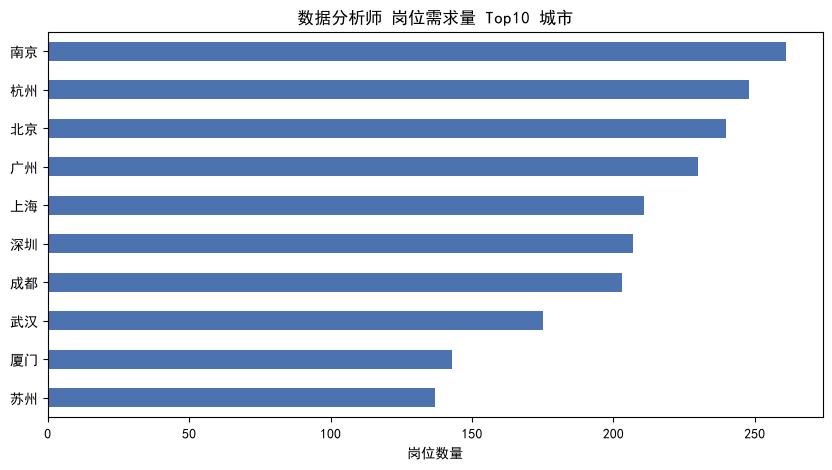

In [10]:
# 画柱状图
city_top = city_count.head(10)
plt.figure(figsize=(10, 5))
city_top.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('数据分析师 岗位需求量 Top10 城市')
plt.xlabel('岗位数量')
plt.ylabel('')
plt.show()


### 4.2 行业分布：哪些行业在大力招聘数据分析人才？


行业
互联网         702
移动互联网       316
计算机软件       248
电子商务        205
数据服务        148
           ... 
印刷/包装/造纸      1
计算机硬件         1
化工            1
石油/石化         1
学前教育          1
Name: count, Length: 79, dtype: int64


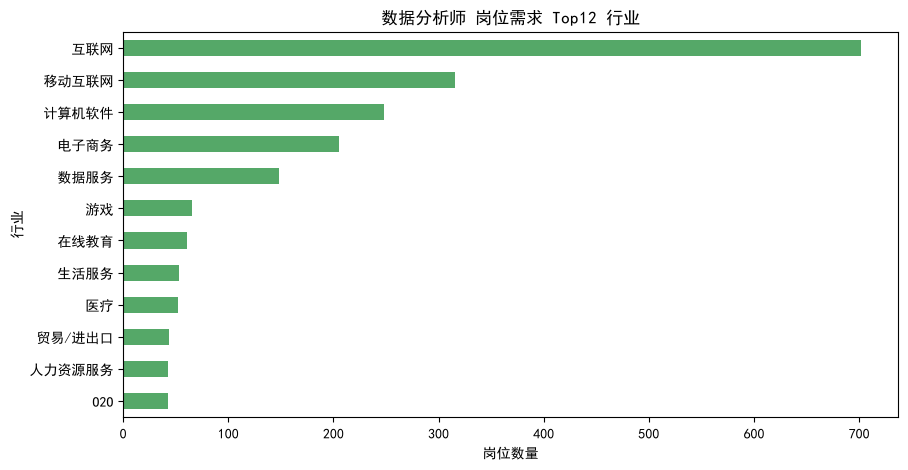

In [27]:
industry_top = df['行业'].value_counts().head(12)
print(df['行业'].value_counts())
plt.figure(figsize=(10, 5))
industry_top.sort_values().plot(kind='barh', color='#55A868')
plt.title('数据分析师 岗位需求 Top12 行业')
plt.xlabel('岗位数量')
plt.show()


### 4.3 经验/学历要求分布


In [12]:
df['经验学历'].value_counts().head(10)


经验学历
3-5年本科     780
1-3年本科     537
5-10年本科    306
经验不限本科     264
1-3年大专     137
3-5年大专      74
经验不限大专      66
3-5年硕士      51
1年以内本科      48
1-3年硕士      43
Name: count, dtype: int64

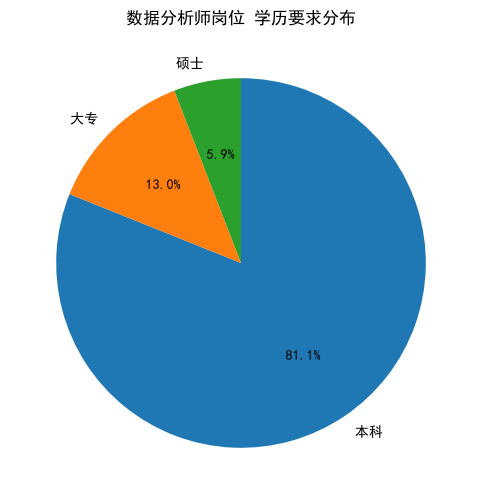

In [13]:
# 学历占比饼图
edu_count = df['学历'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(edu_count, labels=edu_count.index, autopct='%1.1f%%',
        startangle=90, counterclock=False)
plt.title('数据分析师岗位 学历要求分布')
plt.show()


### 4.4 薪资分布


In [14]:
df['薪资中位'].describe()


count    2501.000000
mean       16.940024
std        11.669662
min         1.500000
25%         7.500000
50%        12.500000
75%        23.000000
max       105.000000
Name: 薪资中位, dtype: float64

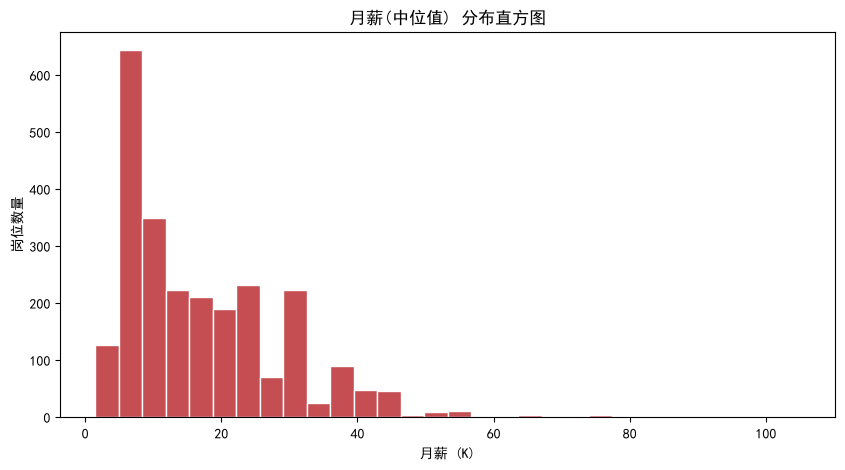

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(df['薪资中位'].dropna(), bins=30, edgecolor='white', color='#C44E52')
plt.title('月薪(中位值) 分布直方图')
plt.xlabel('月薪 (K)')
plt.ylabel('岗位数量')
plt.show()


## 第五步：交叉分析（两个字段一起看，信息量更大）

到这里开始进入到「洞察」阶段——单看一个字段只能知道"有什么"，交叉了才能知道"谁高谁低、有没有规律"。


### 5.1 城市 × 薪资：不同城市薪酬水平对比


城市
北京    30.00
杭州    25.00
上海    22.50
深圳    22.50
广州    16.25
成都    10.00
南京     9.00
厦门     8.75
长沙     8.50
武汉     8.50
Name: 薪资中位, dtype: float64


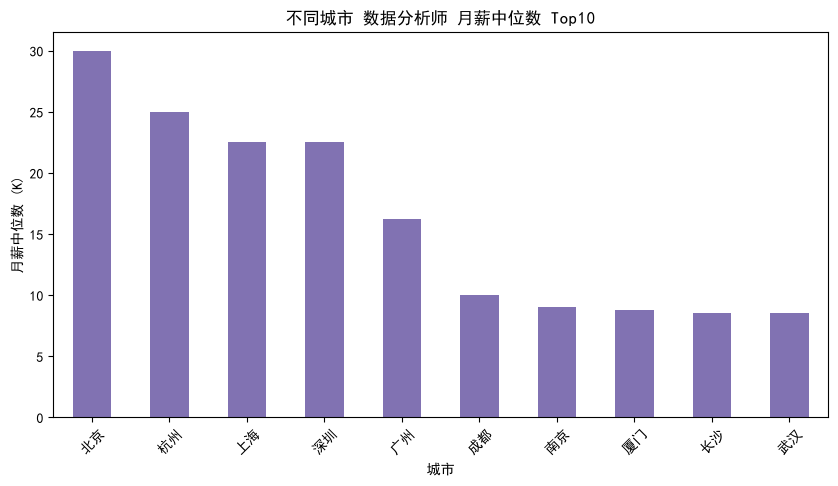

In [24]:
city_salary = df.groupby('城市')['薪资中位'].median().sort_values(ascending=False)
city_salary.head(10)
print(city_salary.head(10))
# 画出来
plt.figure(figsize=(10, 5))
city_salary.head(10).plot(kind='bar', color='#8172B2')
plt.title('不同城市 数据分析师 月薪中位数 Top10')
plt.ylabel('月薪中位数 (K)')
plt.xticks(rotation=45)
plt.show()


### 5.2 行业 × 薪资：哪些行业给得更高？


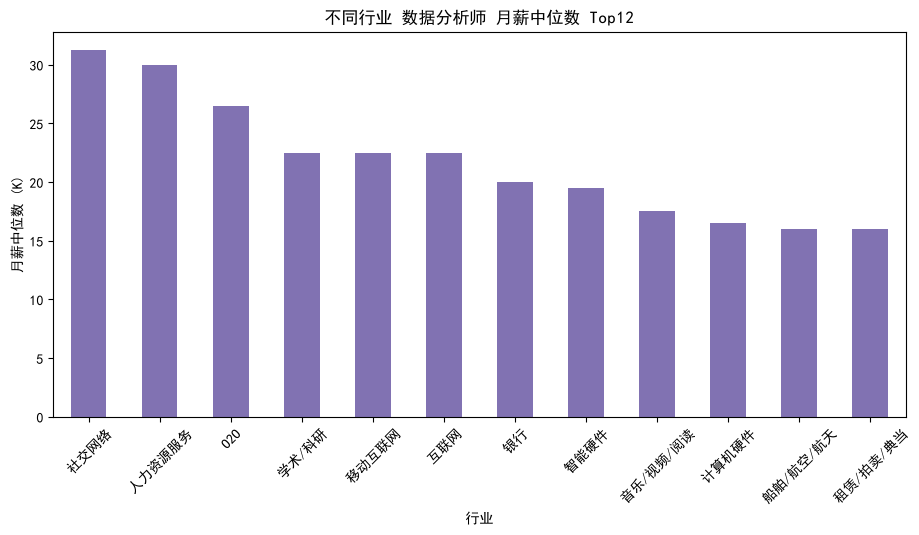

In [17]:
industry_salary = df.groupby('行业')['薪资中位'].median().sort_values(ascending=False)
plt.figure(figsize=(11, 5))
industry_salary.head(12).plot(kind='bar', color='#8172B2')
plt.title('不同行业 数据分析师 月薪中位数 Top12')
plt.ylabel('月薪中位数 (K)')
plt.xticks(rotation=45)
plt.show()


### 5.3 经验年资 × 薪资：涨薪曲线长什么样？


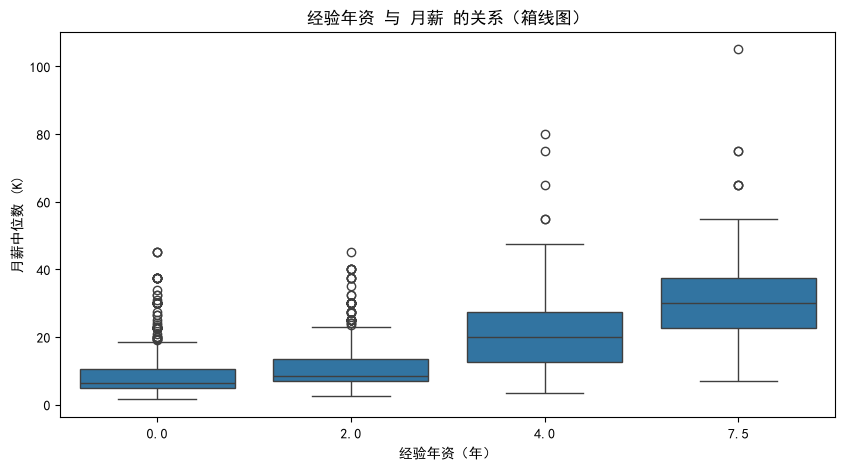

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df.dropna(subset=['经验年资', '薪资中位']),
            x='经验年资', y='薪资中位')
plt.title('经验年资 与 月薪 的关系（箱线图）')
plt.xlabel('经验年资（年）')
plt.ylabel('月薪中位数 (K)')
plt.show()


### 5.4 技能需求：「会什么」更吃香？


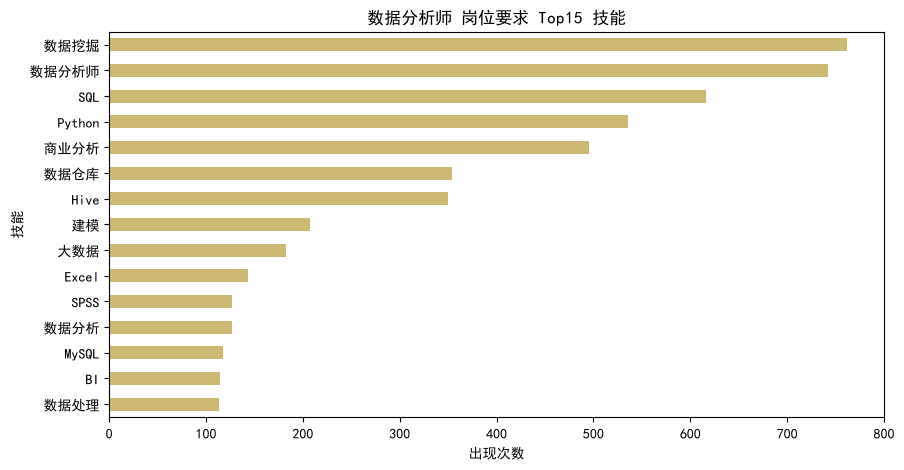

In [19]:
skill_top = all_skills.value_counts().head(15)
plt.figure(figsize=(10, 5))
skill_top.sort_values().plot(kind='barh', color='#CCB974')
plt.title('数据分析师 岗位要求 Top15 技能')
plt.xlabel('出现次数')
plt.show()


### 5.5 技能词云

找到的字体路径： C:\Windows\Fonts\simhei.ttf


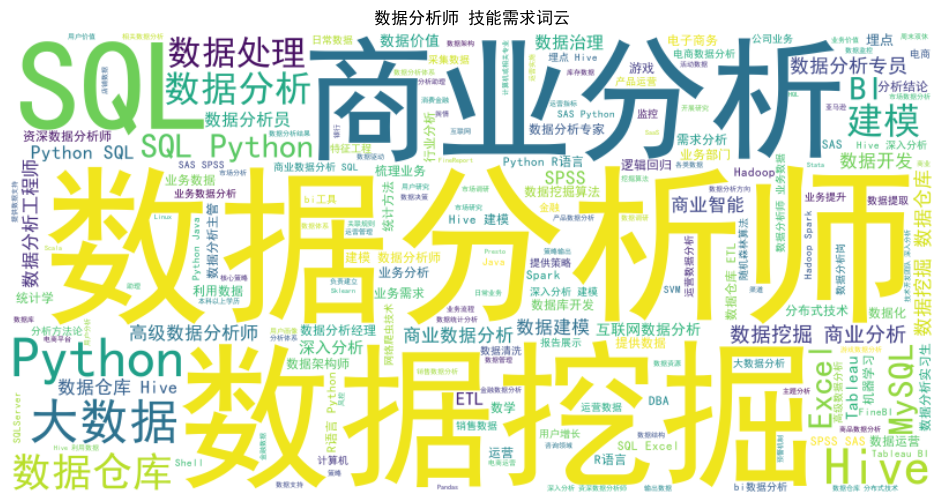

In [38]:

from wordcloud import WordCloud
import matplotlib.font_manager as fm
font_path=None
for f in fm.findSystemFonts():
    if any(k in f.lower() for k in ['simhei', 'msyh', 'SimsunExtG.ttf', 'notosanscjk', 'pingfang', 'arial unicode']):
        font_path = f
        break
print("找到的字体路径：", font_path)
wc = WordCloud(width=800, height=400, background_color='white',
               font_path=font_path).generate(' '.join(all_skills))

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('数据分析师 技能需求词云')
plt.show()


## 第六步：得出结论（故事收尾）

### 主要发现

1. **岗位需求集中度**：数据分析师岗位需求最大的城市是 __南京____、_杭州_____，Top10 城市占全部岗位约 __81__%。
2. **行业倾向**：需求最旺盛的行业是 __互联网____（约 __702__ 条），薪资中位数最高的行业是 ___社交网络___。
3. **薪酬水平**：全市月薪中位数约为 _____12.5_ K，薪资范围集中在 __7____ K ~ ___23___ K。
4. **经验溢价**：从箱线图看，经验年资越高，薪资整体 ___上升___（上升/下降）。
5. **技能门槛**：出现频率最高的技能是 ___数据挖掘___、__数据分析____、___SQL___，说明 ___数据挖掘___ 是硬通货。

### 对数字化 HR 的启示

- 本文描绘了「数据分析师」这个数字化岗位的**供给侧画像**，可作为 HR 做**人才供给调研、薪酬对标、招聘岗位 JD 设计**的数据依据。
- 将「技能—薪资」结合，可辅助构建**人才能力模型 / 薪酬宽带**。
- 该分析流程（清洗→单维→交叉→结论）可复用到**其他岗位、其他城市**数据上，形成一套可复用的 **招聘数据分析模板**。


